In [ ]:
# install package
!pip3 install -U ucimlrepo


In [ ]:
# Load dataset
from ucimlrepo import fetch_ucirepo


# fetch dataset
phishing_websites = fetch_ucirepo(id=327)


#  data (as pandas dataframes)
X = phishing_websites.data.features
y = phishing_websites.data.targets.squeeze()


# metadata
print(phishing_websites.metadata)


# variable information
print(phishing_websites.variables)

{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

In [ ]:
# preview datase
X.head()


,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1


In [ ]:
y.head()

,result
0,-1
1,-1
2,-1
3,-1
4,1


In [ ]:
# check dataset dimensions
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (11055, 30)
Shape of y: (11055,)


In [ ]:
# check target distribution
y.value_counts()


,count
result,
1,6157
-1,4898


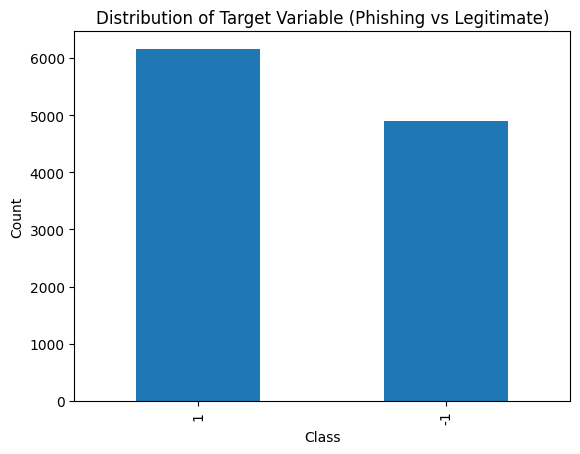

In [ ]:
# Plot charts
import matplotlib.pyplot as plt


# plot distribution of target variable
y.value_counts().plot(kind='bar')
plt.title("Distribution of Target Variable (Phishing vs Legitimate)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


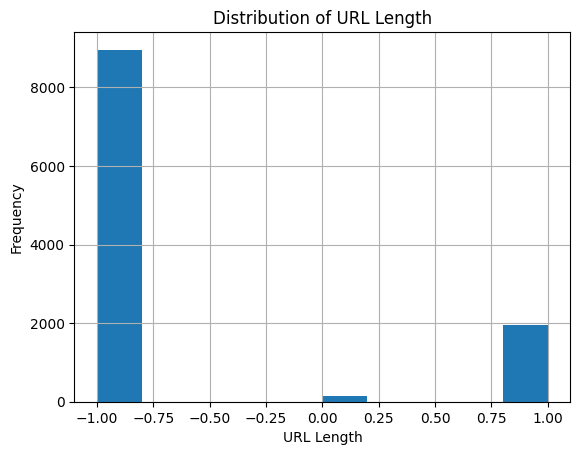

In [ ]:
# plot distribution of URL length
X['url_length'].hist()
plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")
plt.show()


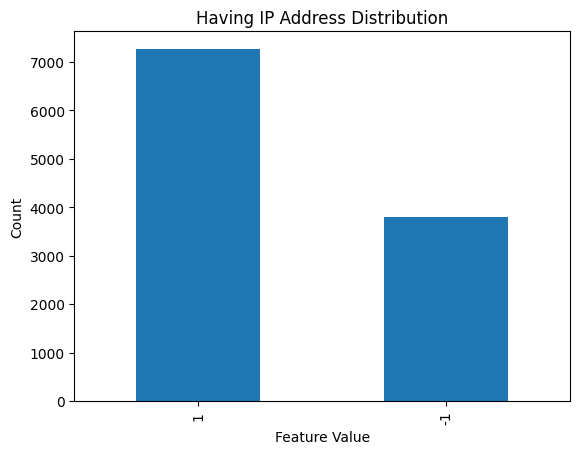

In [ ]:
# plot distribution of having IP address feature
X['having_ip_address'].value_counts().plot(kind='bar')
plt.title("Having IP Address Distribution")
plt.xlabel("Feature Value")
plt.ylabel("Count")
plt.show()


In [ ]:
# Train, test split
from sklearn.model_selection import train_test_split


# split data into training (70%) and testing (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
# Model fitting
from sklearn.tree import DecisionTreeClassifier


# test different depths
for depth in [3, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, criterion='entropy', random_state=42)
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"Depth: {depth}, Accuracy: {accuracy}")


Depth: 3, Accuracy: 0.9083509195055773
Depth: 5, Accuracy: 0.9231233041905336
Depth: None, Accuracy: 0.964124208622249


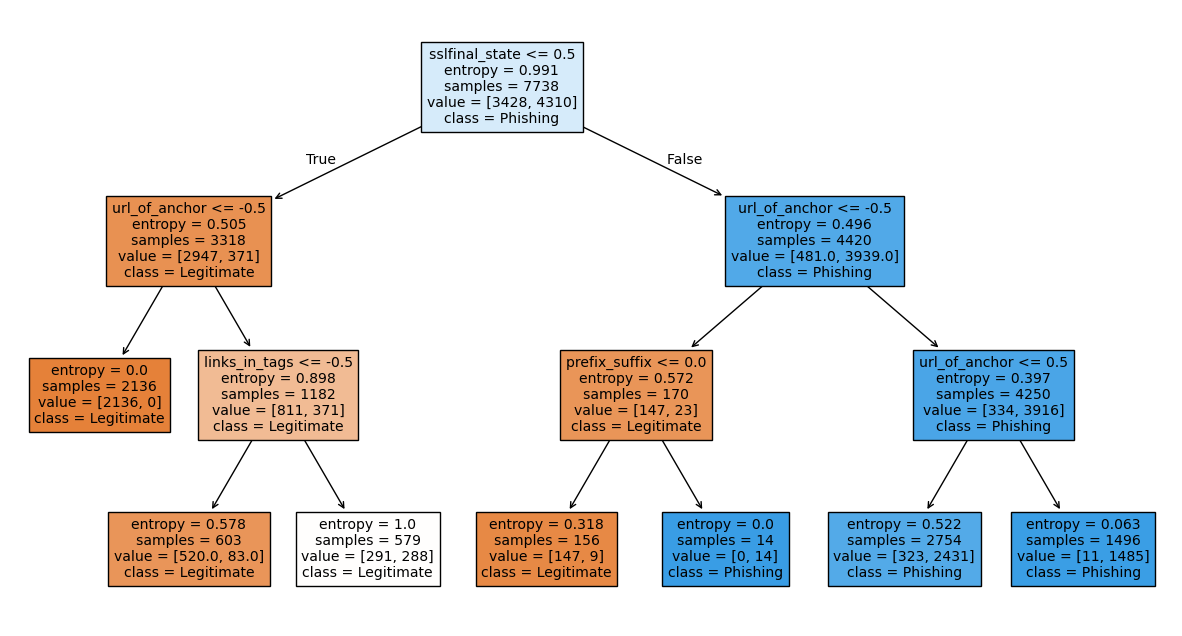

In [ ]:
# Tree visualizacion (Small)
from sklearn.tree import plot_tree

# train smaller tree for easier interpretation
model_small = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
model_small.fit(X_train, y_train)


# plot simplified decision tree
plt.figure(figsize=(15,8))
plot_tree(model_small, feature_names=X.columns, class_names=['Legitimate','Phishing'], filled=True)
plt.show()


In [ ]:
# train final model using best-performing depth
model = DecisionTreeClassifier(max_depth=None, criterion='entropy', random_state=42)
model.fit(X_train, y_train)



DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
# generate predictions on test data
y_pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


# compute evaluation metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, pos_label=1)
rec = recall_score(y_test, y_pred, pos_label=1)


print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)


Confusion Matrix:
 [[1402   68]
 [  51 1796]]
Accuracy: 0.964124208622249
Precision: 0.9635193133047211
Recall: 0.9723876556578235


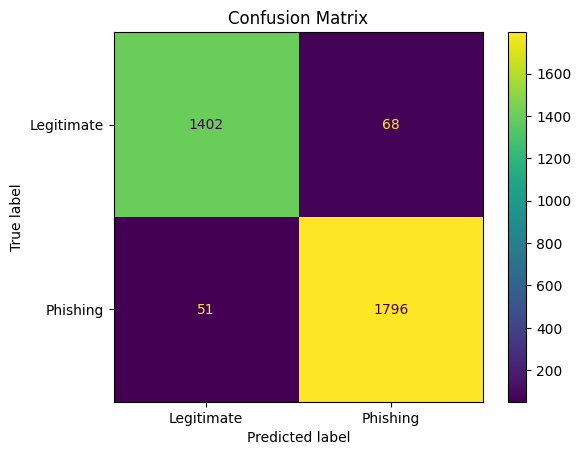

In [ ]:
# Confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate','Phishing']).plot()
plt.title("Confusion Matrix")
plt.show()
